In [ ]:
#uploaded = files.upload()

Saving booking_hotel.csv to booking_hotel.csv


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("Notebook environment working!")

Notebook environment working!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [197]:
df = pd.read_csv('/content/booking_hotel.csv', encoding='latin1')
df.head()

,Hotel Name,Location,Rating,Review Score,Number of,Room Score,Room Type,Bed Type,Room Price (in BDT or any other currency)
0,Krabi La Playa Resort - SHA Plus,Ao Nang Beach,8.2,Very Good,141,8.6,Deluxe Double or Twin Room,1 double or 2 twins,"146,026"
1,KC Beach Club & Pool Villas,"Chaweng City Center , Chaweng",7.1,Good,193,NaN,Double Room with Balcony and Sea View,1 queen bed,"215,304"
2,Rawai VIP Villas & Kids Park,Rawai Beach,8.3,Very Good,63,8.9,2 Bedroom Pool Villa,2 queen beds,"435,384"
3,"FuramaXclusive Sathorn, Bangkok","Bang Rak, Bangkok",7.7,Good,"1,304",8.1,Executive Double Room,1 full bed,"146,240"
4,Bo Phut Resort and Spa - SHA Plus,Bophut,9.3,Wonderful,294,9.6,Villa with Garden View,1 double or 2 twins,"621,072"


In [186]:
# Data Understanding
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

Shape: (3465, 14)

Columns:
 Index(['Hotel Name', 'Location', 'Rating', 'Review Score', 'Number of   ',
       'Room    Score', 'Room Type', 'Bed Type',
       'Room Price (in BDT or any other currency)', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'total_stay', 'Price Category',
       'Rating Category'],
      dtype='object')

Data Types:
 Hotel Name                                     object
Location                                       object
Rating                                        float64
Review Score                                   object
Number of                                     float64
Room    Score                                 float64
Room Type                                      object
Bed Type                                       object
Room Price (in BDT or any other currency)       int64
stays_in_weekend_nights                         int64
stays_in_week_nights                            int64
total_stay                                      

In [190]:
# Data Cleaning & Preprocessing
df = df.ffill()
df = df.drop_duplicates()
df.columns = df.columns.str.strip()
if 'Rating' in df.columns:
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

price_col = 'Room Price (in BDT or any other currency)'
if price_col in df.columns:
    df[price_col] = pd.to_numeric(
        df[price_col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
        errors='coerce'
    )

print("After cleaning:", df.shape)

After cleaning: (2637, 11)


In [203]:
# Feature Engineering
# Price Category
col = 'Room Price (in BDT or any other currency)'
df[col] = pd.to_numeric(
    df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)
df['Price Category'] = pd.cut(df[col],
                             bins=[0, 50000, 250000, 500000, df[col].max()],
                             labels=['Low', 'Medium', 'High', 'Luxury'])

df.head()

# Rating Category
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Rating Category'] = pd.cut(df['Rating'],
                              bins=[0, 4, 6, 8, 10],
                              labels=['Poor', 'Average', 'Good', 'Excellent'])
df.head()


,Hotel Name,Location,Rating,Review Score,Number of,Room Score,Room Type,Bed Type,Room Price (in BDT or any other currency),Price Category,Rating Category
0,Krabi La Playa Resort - SHA Plus,Ao Nang Beach,8.2,Very Good,141,8.6,Deluxe Double or Twin Room,1 double or 2 twins,146026,Medium,Excellent
1,KC Beach Club & Pool Villas,"Chaweng City Center , Chaweng",7.1,Good,193,NaN,Double Room with Balcony and Sea View,1 queen bed,215304,Medium,Good
2,Rawai VIP Villas & Kids Park,Rawai Beach,8.3,Very Good,63,8.9,2 Bedroom Pool Villa,2 queen beds,435384,High,Excellent
3,"FuramaXclusive Sathorn, Bangkok","Bang Rak, Bangkok",7.7,Good,"1,304",8.1,Executive Double Room,1 full bed,146240,Medium,Good
4,Bo Phut Resort and Spa - SHA Plus,Bophut,9.3,Wonderful,294,9.6,Villa with Garden View,1 double or 2 twins,621072,Luxury,Excellent


In [183]:
# Subgroup Comparisons
# Location vs Average Rating
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
print(df.groupby('Location')['Rating'].mean().sort_values(ascending=False).head(10))

# Room Type vs Average Price
col = 'Room Price (in BDT or any other currency)'
df[col] = pd.to_numeric(
    df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)
print(df.groupby('Room Type')[col].mean().sort_values(ascending=False))


Location
Ban Nam Cham               10.0
Arenales del Sol            9.8
Cabrerizos                  9.8
Moclín                      9.8
Ban Khao Yai Chum           9.7
Ferreries                   9.7
Sathorn, Thung Maha Mek     9.7
Chío                        9.7
Lekeitio                    9.7
Torrox                      9.7
Name: Rating, dtype: float64
Room Type
One Bedroom Residence                              4804680.0
Executive Suite with Sea View and Spa Access       4149140.0
Penthouse Suite Red Level                          4065292.0
Prestige Suite                                     3642429.0
Art Deco Queen, Guest room, 1 Queen                2744278.0
                                                     ...    
Bed in 4-Bed Dormitory Room                          27107.0
Double Room with Fan                                 26007.0
Double or Twin Room with Shared Bathroom             25231.0
Standard Twin Room with Fan                          20689.0
Standard Twin Room wit

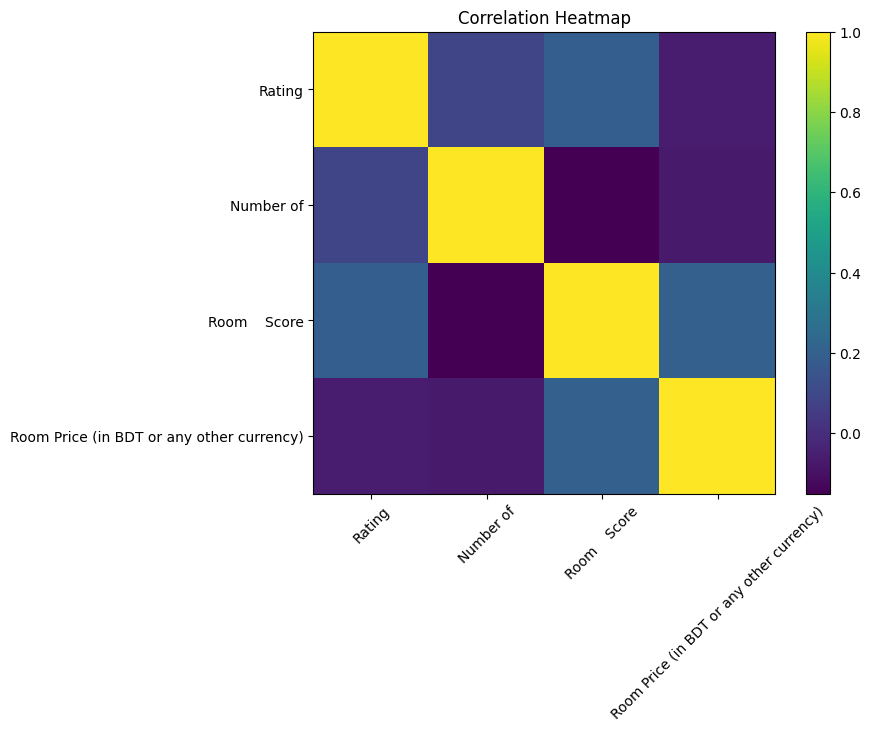

In [196]:
# Relationship Analysis (Correlation Heatmap)
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [192]:
# Analysis
if 'Rating' in df.columns:
    print("Average Rating:", df['Rating'].mean())

if 'Location' in df.columns:
    print("\nTop Locations:\n", df['Location'].value_counts().head())

if 'Room Type' in df.columns:
    print("\nRoom Type Count:\n", df['Room Type'].value_counts())

price_col = 'Room Price (in BDT or any other currency)'
if price_col in df.columns:
    print("\nAverage Price:", df[price_col].mean())

review_cols = [c for c in df.columns if 'review' in c.lower()]
if review_cols:
    col = review_cols[0]
    print("\nTop Hotels by Reviews:\n",
          df.sort_values(by=col, ascending=False)[['Hotel Name', col]].head())


Average Rating: 8.105422828972317

Top Locations:
 Location
8th arr., Paris         45
Khlong Toei, Bangkok    26
Patong Beach            25
16th arr., Paris        24
Orchard, Singapore      21
Name: count, dtype: int64

Room Type Count:
 Room Type
One-Bedroom Apartment                                           168
Double Room                                                     105
Double or Twin Room                                             103
Two-Bedroom Apartment                                           101
Standard Double Room                                             82
                                                               ... 
Executive Floor Deluxe King Room                                  1
Twin Deluxe Room                                                  1
Deluxe Room King Bed, Garden View                                 1
Premium Studio                                                    1
Deluxe Pool View Twin, Deluxe Guest room, Pool view, Balcony      1
Na

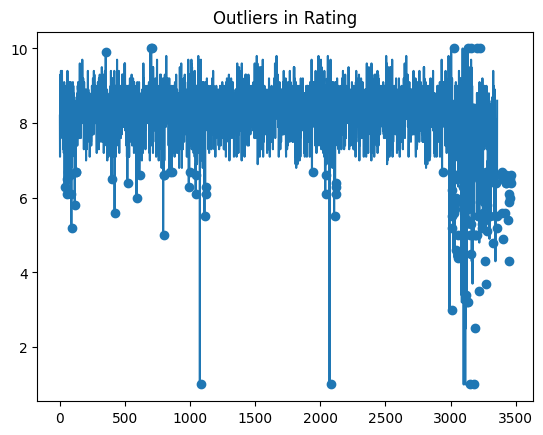

In [171]:
# Outlier Analysis
data = pd.to_numeric(df['Rating'], errors='coerce').dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

outliers = data[(data < Q1 - 1.5*(Q3-Q1)) | (data > Q3 + 1.5*(Q3-Q1))]

plt.plot(data.values)
plt.scatter(outliers.index, outliers.values)

plt.title("Outliers in Rating")
plt.show()

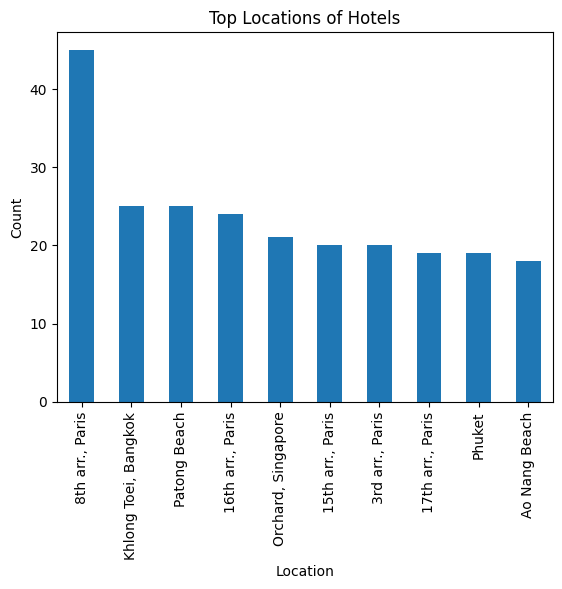

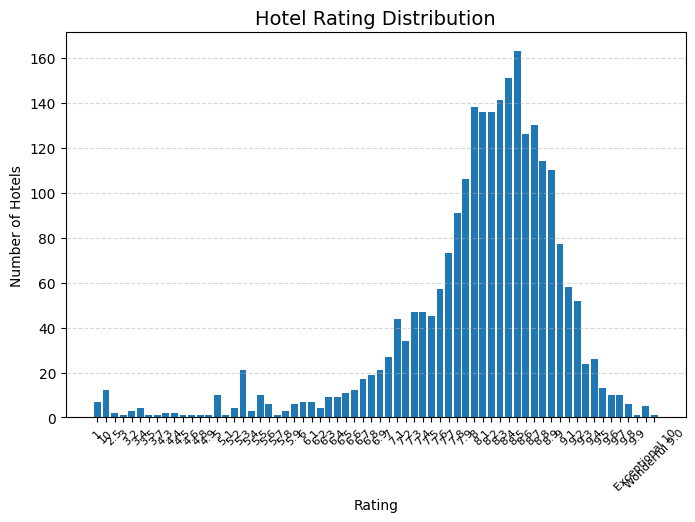

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 149 (\x95) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


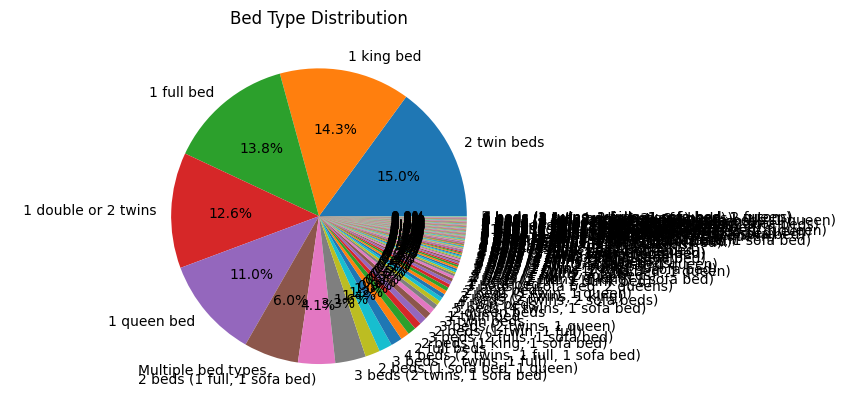

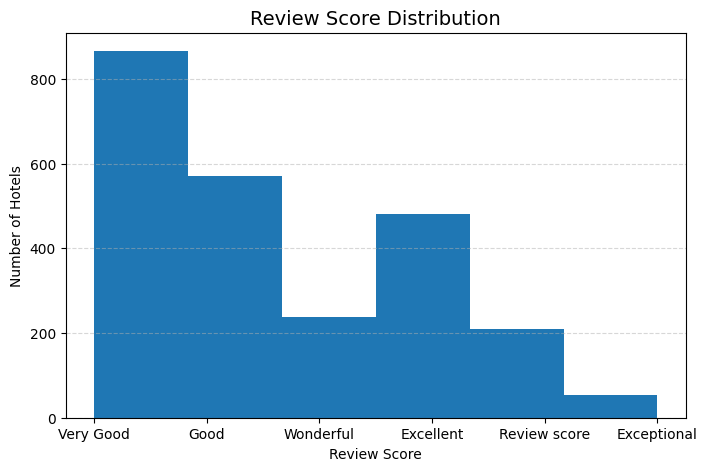

In [127]:
# Visualizations
# Hotel Location Distribution
plt.figure()
df['Location'].value_counts().head(10).plot(kind='bar')
plt.title("Top Locations of Hotels")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

# Rating Distribution
plt.figure(figsize=(8,5))
rating_counts = df['Rating'].round(1).value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Hotel Rating Distribution", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Number of Hotels")
plt.xticks(rotation=45, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Bed Type Pie Chart
plt.figure()
df['Bed Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Bed Type Distribution")
plt.ylabel("")
plt.show()

#Review Score Distribution
plt.figure(figsize=(8,5))
scores = df['Review Score'].dropna()
plt.hist(scores, bins=6)
plt.title("Review Score Distribution", fontsize=14)
plt.xlabel("Review Score")
plt.ylabel("Number of Hotels")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [194]:
# Findings
print("Findings:\n")
print("1. Room prices show significant variation, with some hotels having very high prices (outliers).")
print("2. Most hotel ratings are within a close range, indicating generally consistent customer satisfaction.")
print("3. Some locations have more hotels and reviews, showing higher popularity among travelers.")
print("4. A few hotels have a very high number of reviews compared to others, indicating uneven customer engagement.")
print("5. Different room types have different average prices, with premium types costing more.")
print("6. There is a weak relationship between price and rating, meaning higher price does not always mean better rating.")



Findings:

1. Room prices show significant variation, with some hotels having very high prices (outliers).
2. Most hotel ratings are within a close range, indicating generally consistent customer satisfaction.
3. Some locations have more hotels and reviews, showing higher popularity among travelers.
4. A few hotels have a very high number of reviews compared to others, indicating uneven customer engagement.
5. Different room types have different average prices, with premium types costing more.
6. There is a weak relationship between price and rating, meaning higher price does not always mean better rating.


In [195]:
# Limitations
print("Limitations:\n")
print("1. The dataset may contain missing or inconsistent values.")
print("2. Data cleaning and conversion may have caused minor data loss.")
print("3. Some variables are categorical, limiting certain types of analysis.")
print("4. The dataset may not represent the entire hotel industry.")
print("5. External factors like location popularity and service quality are not included.")

Limitations:

1. The dataset may contain missing or inconsistent values.
2. Data cleaning and conversion may have caused minor data loss.
3. Some variables are categorical, limiting certain types of analysis.
4. The dataset may not represent the entire hotel industry.
5. External factors like location popularity and service quality are not included.
